# EX3 — Straight-line motion: two controllers and a mixer

**What you will see**
* The micromouse controller structure: a **forward** loop on the *average* encoder count and a
  **heading** loop on the *difference*, mixed into two PWMs.
* Scenario A: open loop → veers (EX1).
* Scenario B: forward loop only → still veers (it controls *how far*, not *which way*).
* Scenario C: forward + heading → straight; P-only leaves a tiny heading offset, I removes it.
* Scenario D: a bump on one wheel → the heading loop recovers.

```
every dt (1 kHz):
  cL, cR = read_encoders()              # atomic copy
  dist   = (cL + cR) / 2                # how far
  diff   =  cL - cR                     # which way
  fwd    = pid_fwd.update(target_dist - dist)
  turn   = pid_head.update(0 - diff)
  set_motors(clamp(fwd + turn), clamp(fwd - turn))
```

In [1]:
from mouse_sim import *

cfg = replace(Config(), mismatch=0.08)      # right motor 8 % weaker, as in EX1
print(cfg.summary())

counts/rev = 360   counts/mm = 3.58   counts/cell = 645   counts/deg (L-R) = 5.00
passage = 168 mm   clearance per side = 34 mm   battery = 8.4 V / 8.4 V


## Encoder arithmetic (do this once for your mouse)
`counts_per_mm = CPR × gear / (π × wheel_diameter)`

In [2]:
print(f"CPR {cfg.cpr} × gear {cfg.gear:.0f} = {cfg.counts_per_rev:.0f} counts per wheel revolution")
print(f"wheel circumference = {2*math.pi*cfg.wheel_r*1000:.1f} mm  →  {cfg.counts_per_mm:.2f} counts/mm")
print(f"one cell (180 mm) = {cfg.counts_per_cell:.0f} counts")

CPR 12 × gear 30 = 360 counts per wheel revolution
wheel circumference = 100.5 mm  →  3.58 counts/mm
one cell (180 mm) = 645 counts


## The control loop (this is the whole thing)

In [3]:
def run_straight(cfg, cells=5, use_fwd=True, use_head=True,
                 kp_f=1.0, ki_f=0.0, kd_f=0.05,
                 kp_h=2.0, ki_h=0.0, kd_h=0.05,
                 base_pwm=150, bump=None, t_max=2.0, seed=0, tf=0.02):
    """bump = (t_bump, counts_lost_on_left) simulates one wheel skidding for an instant."""
    m = DiffDrive(cfg, seed=seed)
    pid_f = PID(kp_f, ki_f, kd_f, tf=tf, umin=-255, umax=255)
    pid_h = PID(kp_h, ki_h, kd_h, tf=tf, umin=-120, umax=120)   # limit steering authority; tf filters D on quantised counts
    target = cells * cfg.counts_per_cell
    n = int(t_max / cfg.dt)
    t = np.arange(n) * cfg.dt
    log = {k: np.zeros(n) for k in ("x", "y", "th", "dist", "diff", "fwd", "turn")}
    bump_offset = 0
    for i in range(n):
        cL, cR = m.counts
        cL += bump_offset
        if bump and abs(t[i] - bump[0]) < cfg.dt / 2:
            bump_offset -= bump[1]                           # the left wheel "lost" counts
        dist = (cL + cR) / 2
        diff = cL - cR
        fwd = pid_f.update(target - dist, cfg.dt) if use_fwd else base_pwm
        turn = pid_h.update(0 - diff, cfg.dt) if use_head else 0.0
        m.step(fwd + turn, fwd - turn)
        for k, v in zip(log, (m.x, m.y, m.theta, dist, diff, fwd, turn)):
            log[k][i] = v
        if not use_fwd and m.x > cells * cfg.cell:          # open-loop runs stop at the end of the corridor
            for k in log: log[k] = log[k][: i + 1]
            t = t[: i + 1]
            break
    return t, log

## Scenarios A, B, C

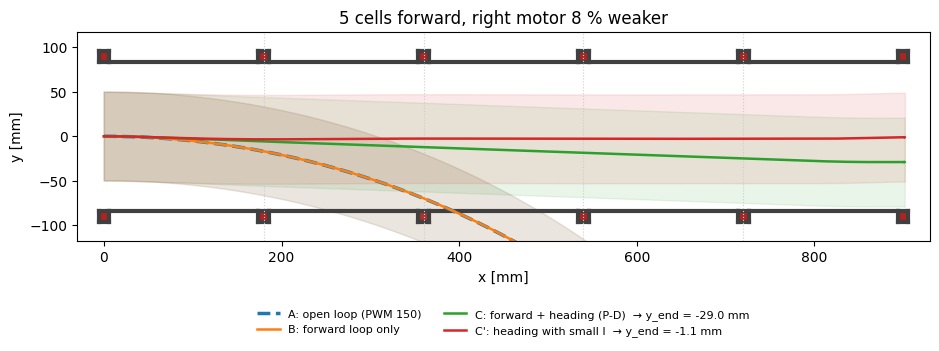

In [4]:
tA, A = run_straight(cfg, use_fwd=False, use_head=False)          # open loop
tB, B = run_straight(cfg, use_fwd=True,  use_head=False)          # forward loop only
tC, C = run_straight(cfg, use_fwd=True,  use_head=True)           # forward + heading (P + D)
tC2, C2 = run_straight(cfg, use_fwd=True, use_head=True, ki_h=20) # + a little I on heading

fig, ax = plt.subplots(figsize=(11, 3.6))
plot_topview(ax, cfg, [
    ("A: open loop (PWM 150)", A["x"], A["y"], {"ls": "--", "lw": 2.5}),
    ("B: forward loop only", B["x"], B["y"]),
    (f"C: forward + heading (P-D)  → y_end = {C['y'][-1]*1000:+.1f} mm", C["x"], C["y"]),
    (f"C': heading with small I  → y_end = {C2['y'][-1]*1000:+.1f} mm", C2["x"], C2["y"]),
], cells=5, title="5 cells forward, right motor 8 % weaker")
savefig(fig, "ex03_scenarios_topview.png")
plt.show()

**Forward loop:** a PID that reads the *average* encoder count (`dist = (cL+cR)/2` — how far the mouse
has actually travelled) and adjusts PWM to drive that distance toward a target (e.g. 5 cells).

**Difference from open loop:** open loop sends a fixed PWM and never checks distance at all — it just
goes until something else stops it. The forward loop measures distance every tick and corrects toward a
target — it *knows* when it's arrived; open loop doesn't.

**Talking points**
* B proves the point: the forward loop stops the mouse after exactly 5 cells of *average* travel — while it drifts sideways.
* C: the heading loop holds `diff ≈ 0`. With P only, the 8 % mismatch needs a constant `turn`, and P needs a constant
  error to produce it: a few counts of steady `diff` → a small heading angle → a slow drift. A small Ki removes it.
* The heading loop's output is capped (±120 PWM) so steering can never take all of the motors' authority.

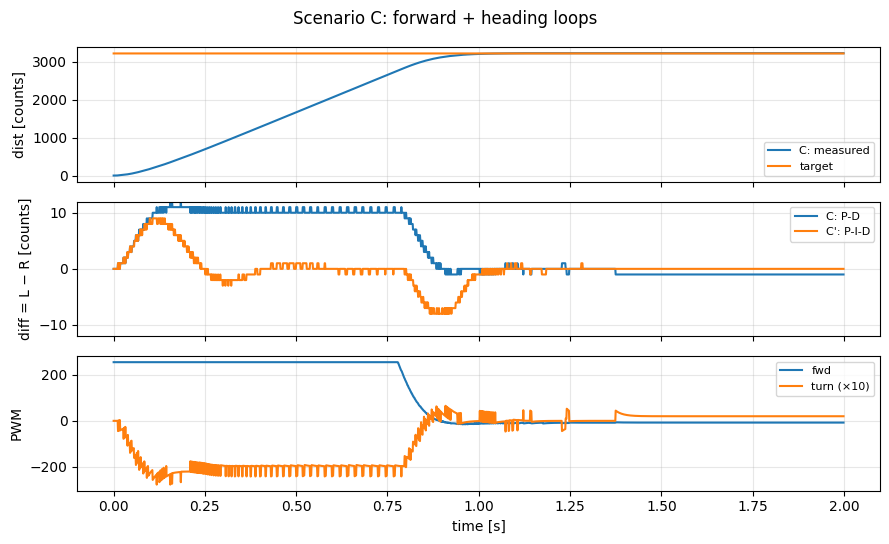

diff while cruising, P-D:   +9.5 counts  →  heading -1.89°  →  y_end -29.0 mm
diff while cruising, P-I-D: +1.2 counts  →  heading -0.24°  →  y_end -1.1 mm


In [5]:
fig, axes = plot_signals(tC, {
    "dist [counts]": {"C: measured": C["dist"], "target": np.full_like(tC, 5 * cfg.counts_per_cell)},
    "diff = L − R [counts]": {"C: P-D": C["diff"], "C': P-I-D": C2["diff"]},
    "PWM": {"fwd": C["fwd"], "turn (×10)": C["turn"] * 10},
}, title="Scenario C: forward + heading loops")
axes[1].set_ylim(-12, 12)
savefig(fig, "ex03_scenarioC_signals.png")
plt.show()
mov = C["fwd"] > 100                                   # while cruising
print(f"diff while cruising, P-D:   {C['diff'][mov].mean():+.1f} counts  →  heading {math.degrees(C['th'][mov].mean()):+.2f}°  →  y_end {C['y'][-1]*1000:+.1f} mm")
print(f"diff while cruising, P-I-D: {C2['diff'][mov].mean():+.1f} counts  →  heading {math.degrees(C2['th'][mov].mean()):+.2f}°  →  y_end {C2['y'][-1]*1000:+.1f} mm")

## Scenario D — one wheel skids: the heading loop recovers
At t = 0.5 s the left encoder "loses" 20 counts (≈ 5.6 mm) in an instant.

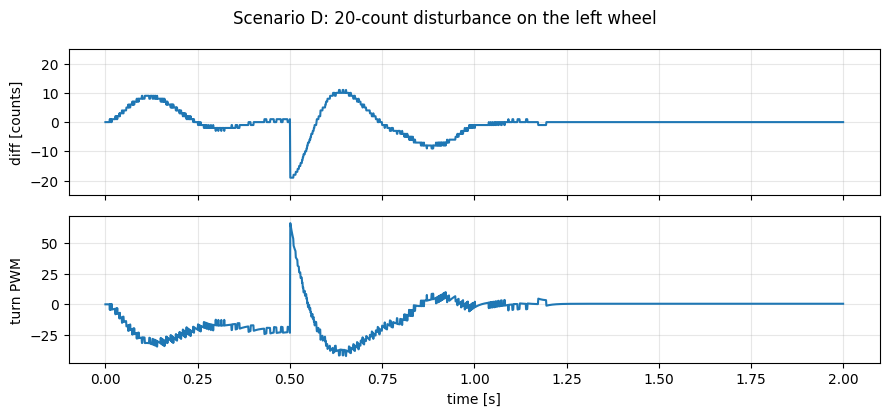

recovered to within 2 counts in 65 ms


In [6]:
tD, D = run_straight(cfg, ki_h=20, bump=(0.5, 20))
fig, axes = plot_signals(tD, {
    "diff [counts]": {"D: bump at 0.5 s": D["diff"]},
    "turn PWM": {"turn": D["turn"]},
}, title="Scenario D: 20-count disturbance on the left wheel", figsize=(9, 4.2))
axes[0].set_ylim(-25, 25)
savefig(fig, "ex03_scenarioD_bump.png")
plt.show()
i0 = int(0.5 / cfg.dt) + 2
rec = tD[np.where(np.abs(D["diff"][i0:]) <= 2)[0][0] + i0] - 0.5
print(f"recovered to within 2 counts in {rec*1000:.0f} ms")

### Goal of EX3

1. **A mouse needs two separate loops, not one.** Forward controls *how far* (average of the encoders);
   heading controls *which way* (difference of the encoders) — same two numbers, two different jobs.

2. **Distance control alone isn't enough.** Scenario B proves it: the forward loop hits the exact target
   distance while still curving into the wall — "how far" and "which way" are genuinely independent
   problems.

3. **The two loops only meet at the mixer** (`fwd + turn`, `fwd − turn`) — steering nudges the base speed,
   it doesn't replace it.

4. **P alone can't cancel a constant fault (motor mismatch).** It always leaves a small steady error
   (Scenario C, −29 mm drift) — a small `Ki` removes it (Scenario C′, −1.1 mm).

5. **The same loop also rejects sudden disturbances fast** (Scenario D: a 20-count skid, corrected in
   ~65 ms) — that's P+D's job, separate from I's job above.

**One line:** *"Two independent PIDs on the same two encoder numbers — forward keeps distance right,
heading keeps direction right, and neither one can do the other's job."*

## Gain preview for EX6 — the heading loop with three Kp values

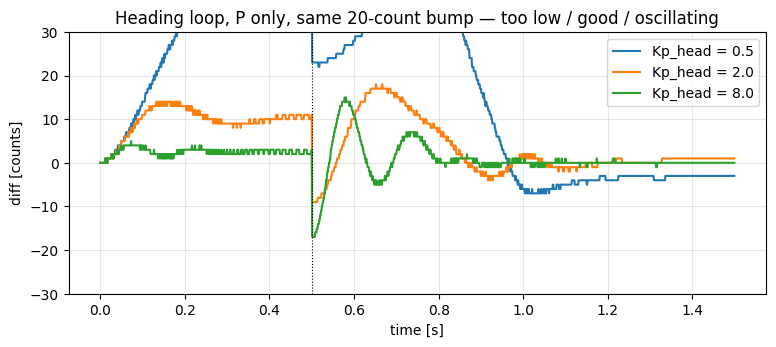

In [7]:
fig, ax = plt.subplots(figsize=(9, 3.4))
for kp in (0.5, 2.0, 8.0):
    tt, R = run_straight(cfg, kp_h=kp, kd_h=0.0, bump=(0.5, 20), t_max=1.5)
    ax.plot(tt, R["diff"], label=f"Kp_head = {kp}")
ax.set_ylim(-30, 30); ax.axvline(0.5, color="k", ls=":", lw=0.8)
ax.set_xlabel("time [s]"); ax.set_ylabel("diff [counts]"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("Heading loop, P only, same 20-count bump — too low / good / oscillating")
savefig(fig, "ex03_kp_preview.png")
plt.show()

## Try this
* `kp_h=8, kd_h=0` → oscillation; add `kd_h=0.3` → gone (EX6 in one line).
* `mismatch=0.15` — how much `turn` is needed? (It is the mismatch × base PWM / 2.)
* Change `cfg.cpr` to 3 (a cheap encoder): watch `diff` become coarse; the heading loop can only resolve ±1 count.

## On your mouse
* Loop at a fixed rate from a timer; read both encoders with interrupts briefly disabled (torn reads!).
* If it veers *more* after enabling the heading loop: flip the sign of `diff` once. Do not fiddle with gains.
* Never call `delay()`/`sleep()` inside the control loop: `dt` stops being `dt`.
* Start gains: `Kp_head` 1–3 PWM/count, `Kd_head` ≈ Kp/20, `Ki_head` 0 until you see a steady drift.